In [205]:
import numpy as np
import pandas as pd
from plotnine import *
import statsmodels.formula.api as smf
import statsmodels.api as sm
from IPython.display import display, Image
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.calibration import calibration_curve


# Supervised Learning

## Motivation

In the last two chapters we introduced linear and logistic regression models.

The primary motivation lied in the interpretation of the coefficients, seen as the effect of explanatory variables on the response adjusted for the effects of other, potentially correlated, variables.

Under some assumptions this even allowed us – holy grail – to conclude about conditional independence. Often, these models were considered as interpretable data generative models, supposed to reflect the underlying process.

In this chapter, we will take a supervised machine learning angle. 

Here, we are interested in good predictions rather than identifying the most predictive features or drawing conclusions about statistical independence.

On the one hand, the goal is less ambitious. On the other hand, focusing on prediction accuracy alone allows unleashing a wide variety of modeling techniques. 

The application area is immense and contains the most prominent successes of today’s artificial intelligence including medical diagnosis, image recognition, automatized translation, etc. 

We will learn how to evaluate the prediction performance on an independent test set and avoid problems related to poor generalization of a model to an independent test set. 

Additionally, we will introduce random forests as an alternative machine learning model for both regression and classification tasks.

-----

# Supervised Learning vs. Unsupervised Learning

Machine learning is the study of computer algorithms that improve automatically through experience. 

Most machine learning problems can be mainly categorized into two: supervised or unsupervised problems. 

<b>In supervised learning</b>, the goal is to build a powerful algorithm that takes feature values as input and returns a prediction for an outcome, even when we do not know the value for the actual outcome. 

For this, we train an algorithm using a data set for which we know the outcome, and then use this trained model to make predictions. In particular, for building the model, we associate each set of feature values to a certain outcome. 

<b>In unsupervised learning</b>, we do not associate feature values to an outcome. The situation is referred to as unsupervised because we lack an outcome variable that can supervise our analysis and model building. Instead, unsupervised learning algorithms identify patterns in the distribution of data. Typically, clustering problems and dimensionality reduction are attributed to unsupervised machine learning problems.

A powerful framework to study supervised and unsupervised learning is statistical learning, which express these problems in statistical terms. Supervised learning then maps to the task of fitting conditional distribution 
 $p(y|x)$ where $y$ 
 is the outcome and $x$ 
 are the features (or fitting aspects of the conditional distribution: the expectation, etc.). Linear regression is one method we already saw.
 
Unsupervised learning in contrast refers to the task of fitting the distribution of the data $p(x)$
, or some aspects of it (covariance: PCA, mixture components: clustering, etc.)

This chapter focuses on supervised learning. In fact, logistic and linear regression are two classical methods in supervised learning for solving classification and regression tasks.

------

# Notation

In this chapter, we will use the classical machine learning nomenclature:

* $y$ denotes the <i>outcome</i> (or response) that we want to predict

* $x_1, x_2, ... , x_p$ denote the <i>features</i> that we will use to predict the outcome.

-------

# Basic Approach in Supervised Machine Learning

In regression and classification tasks, we have a series of features and an unknown numeric or categorial outcome we want to predict:

In [206]:
df_new = pd.DataFrame({
    "outcome": ["?"],
    "feature_1": ["x1"],
    "feature_2": ["x2"],
    "feature_3": ["x3"],
    "feature_4": ["x4"],
    "feature_5": ["x5"],
})

df_new

,outcome,feature_1,feature_2,feature_3,feature_4,feature_5
0,?,x1,x2,x3,x4,x5


In [207]:
df_train = pd.DataFrame({
    "outcome": ["y1", "y2", "y3", "y4", "y5",
                "y6", "y7", "y8", "y9", "y10"],
    "feature_1": ["x1,1", "x2,1", "x3,1", "x4,1", "x5,1",
                  "x6,1", "x7,1", "x8,1", "x9,1", "x10,1"],
    "feature_2": ["x1,2", "x2,2", "x3,2", "x4,2", "x5,2",
                  "x6,2", "x7,2", "x8,2", "x9,2", "x10,2"],
    "feature_3": ["x1,3", "x2,3", "x3,3", "x4,3", "x5,3",
                  "x6,3", "x7,3", "x8,3", "x9,3", "x10,3"],
    "feature_4": ["x1,4", "x2,4", "x3,4", "x4,4", "x5,4",
                  "x6,4", "x7,4", "x8,4", "x9,4", "x10,4"],
    "feature_5": ["x1,5", "x2,5", "x3,5", "x4,5", "x5,5",
                  "x6,5", "x7,5", "x8,5", "x9,5", "x10,5"],
})

df_train

,outcome,feature_1,feature_2,feature_3,feature_4,feature_5
0,y1,"x1,1","x1,2","x1,3","x1,4","x1,5"
1,y2,"x2,1","x2,2","x2,3","x2,4","x2,5"
2,y3,"x3,1","x3,2","x3,3","x3,4","x3,5"
3,y4,"x4,1","x4,2","x4,3","x4,4","x4,5"
4,y5,"x5,1","x5,2","x5,3","x5,4","x5,5"
5,y6,"x6,1","x6,2","x6,3","x6,4","x6,5"
6,y7,"x7,1","x7,2","x7,3","x7,4","x7,5"
7,y8,"x8,1","x8,2","x8,3","x8,4","x8,5"
8,y9,"x9,1","x9,2","x9,3","x9,4","x9,5"
9,y10,"x10,1","x10,2","x10,3","x10,4","x10,5"


We use this data to train the model and then use the trained model to apply to our (new) data for which we do not know the outcome.

Now… how do we evaluate our model? And how do we make sure our model will perform well on our (new) data?

------

# Over- and Under-fitting

Analyzing whether our built model is generalizing well and capturing the trend of the data is an essential aspect of supervised machine learning.

Two situations should be avoided: 
    
* that the model does not capture the trends of the data resulting in a high measured error between actual and predicted outcomes (under-fitting)

* that the model does not generalize well but fits the data used for training the model too well (over-fitting).



## Example: Polynomial Curve Fitting

As an example, we consider a polynomial curve fitting as a regression task with a dataset of $n=10$ points shown in each comprising an observation of the input variable $x$ along with the corresponding outcome variable 
. 

In this example, the data is generated from the function

$$
f(x) = \sin(2\pi x)
$$

(shown in blue) with added random noise from a normal distribution.

In [208]:
np.random.seed(57)

n = 10

points = np.linspace(0,1,n)
sin_p = np.sin(2*np.pi*points)
noise = np.random.normal(loc = 0, scale= 0.2, size = len(points))

df = pd.DataFrame({
    'x' : points,
    'y' : sin_p + noise 
})


sin_x = np.linspace(0,1,100)
sin_y = np.sin(2*np.pi*sin_x)

df_sin = pd.DataFrame({
    'x' : sin_x,
    'y' : sin_y
})

df.head()

,x,y
0,0.000000,-0.026210
1,0.111111,0.602658
2,0.222222,0.646783
3,0.333333,0.707142
4,0.444444,0.647620


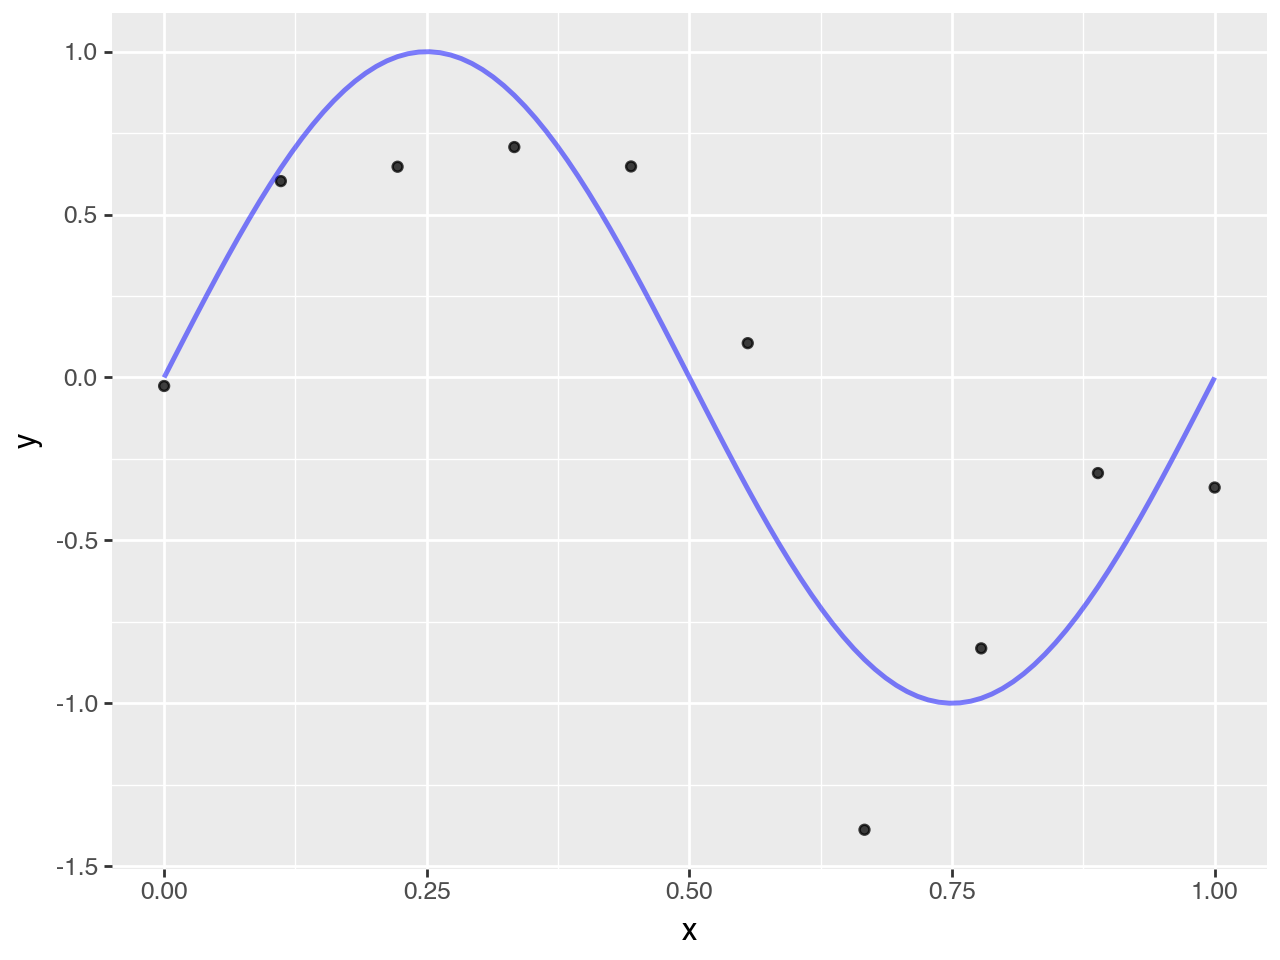

In [209]:
(
    ggplot(df, aes('x', 'y')) +
    geom_point(alpha = 0.75) +
    geom_line(df_sin, aes('x', 'y'), color='blue', size=1, alpha = 0.5)
)

Assuming that we do not know the function plotted in the blue curve, the goal is to predict the value of $y$ 
for some new arbitrary value of $x$. 
 
For this, we want to exploit the given dataset of $n$
data points in order to make predictions of the value $y$
 of the outcome variable for some new value 
, which involves implicitly trying to discover the underlying function $f(x) = \sin(2\pi x)$
. 

This is a difficult problem considering that we have to generalize from a finite dataset of only $n$
 points. Furthermore, the given data points include noise, and so for a given $x$
, there is a certain uncertainty regarding the correct value for $y$
.

We consider a simple approach based on curve fitting to make predictions for a given value of $x$. 

More precisely, we fit the data using a polynomial function of the form:

$$
y(x,\boldsymbol{\beta}) = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_m x^m = \sum_{j=0}^{m} \beta_j x^{j}
$$


Here, $m$
 is the order of the polynomial function and $x_j$
 denotes $x$
 raised to the power of $j$
. 

The polynomial coefficients $\beta_0,\beta_1,..., \beta_m$
 are denoted by the vector $\beta$
. 

Note that, the polynomial function $y(x,\beta)$
 is a nonlinear function of $x$
 but it is a linear function of the coefficients $\beta$
. 

Hence, a linear regression model (see Chapter (chap-lin-reg?)) can be applied to find optimal values of $\beta$
assuming that we have selected a value for the order $m$
of the polynomial fit.

As described in Chapter (chap-lin-reg?), an optimal linear model (with optimal $\beta$
 values) can be found by minimizing an error function (sum of squared errors) that measures the misfit between the function $y(x,\beta)$
 and the data points in the considered dataset.

Selecting different values for the order $m$
of the polynomial has a huge impact on the resulting model.

In below figure, we show four examples of the results of fitting polynomials with different orders $m = 0,1,3$ and $9$
and 
to our dataset of $n = 100$
points.

In [210]:
for i in range(1,10):
    df['x_'+str(i)] = np.pow(df['x'], i)

df.head()

,x,y,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9
0,0.000000,-0.026210,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
1,0.111111,0.602658,0.111111,0.012346,0.001372,0.000152,0.000017,0.000002,2.090752e-07,2.323057e-08,2.581175e-09
2,0.222222,0.646783,0.222222,0.049383,0.010974,0.002439,0.000542,0.000120,2.676162e-05,5.947027e-06,1.321561e-06
3,0.333333,0.707142,0.333333,0.111111,0.037037,0.012346,0.004115,0.001372,4.572474e-04,1.524158e-04,5.080526e-05
4,0.444444,0.647620,0.444444,0.197531,0.087791,0.039018,0.017342,0.007707,3.425487e-03,1.522439e-03,6.766395e-04


In [211]:
fit_model_x1 = smf.ols('y ~ x_1', df).fit()
fit_model_x3 = smf.ols('y ~ x_1 + x_2 + x_3',df).fit()
fit_model_x9 = smf.ols('y ~ x_1 + x_2 + x_3 + x_4 + x_5 + x_6 + x_7 + x_8 + x_9', df).fit()

In [212]:
df['pred_0'] = df['y'].mean()
df['pred_1'] = fit_model_x1.predict(df)
df['pred_3'] = fit_model_x3.predict(df)
df['pred_9'] = fit_model_x9.predict(df)

new_df = df[['x', 'y', 'pred_0', 'pred_1', 'pred_3', 'pred_9']]

In [213]:
x = np.linspace(0,1,100)
X_pred = pd.DataFrame({'x': x})

for i in range(1,10):
    X_pred['x_'+str(i)] = np.pow(X_pred['x'], i)

X_pred['degree_0'] = [df['y'].mean()] * len(x)
X_pred['degree_1'] = fit_model_x1.predict(X_pred)
X_pred['degree_3'] = fit_model_x3.predict(X_pred)
X_pred['degree_9'] = fit_model_x9.predict(X_pred)


X_pred = X_pred.melt(id_vars= ['x'], value_vars= ['degree_0','degree_1', 'degree_3', 'degree_9'], var_name= 'degree', value_name= 'est')
X_pred.head()

,x,degree,est
0,0.000000,degree_0,-0.016806
1,0.010101,degree_0,-0.016806
2,0.020202,degree_0,-0.016806
3,0.030303,degree_0,-0.016806
4,0.040404,degree_0,-0.016806


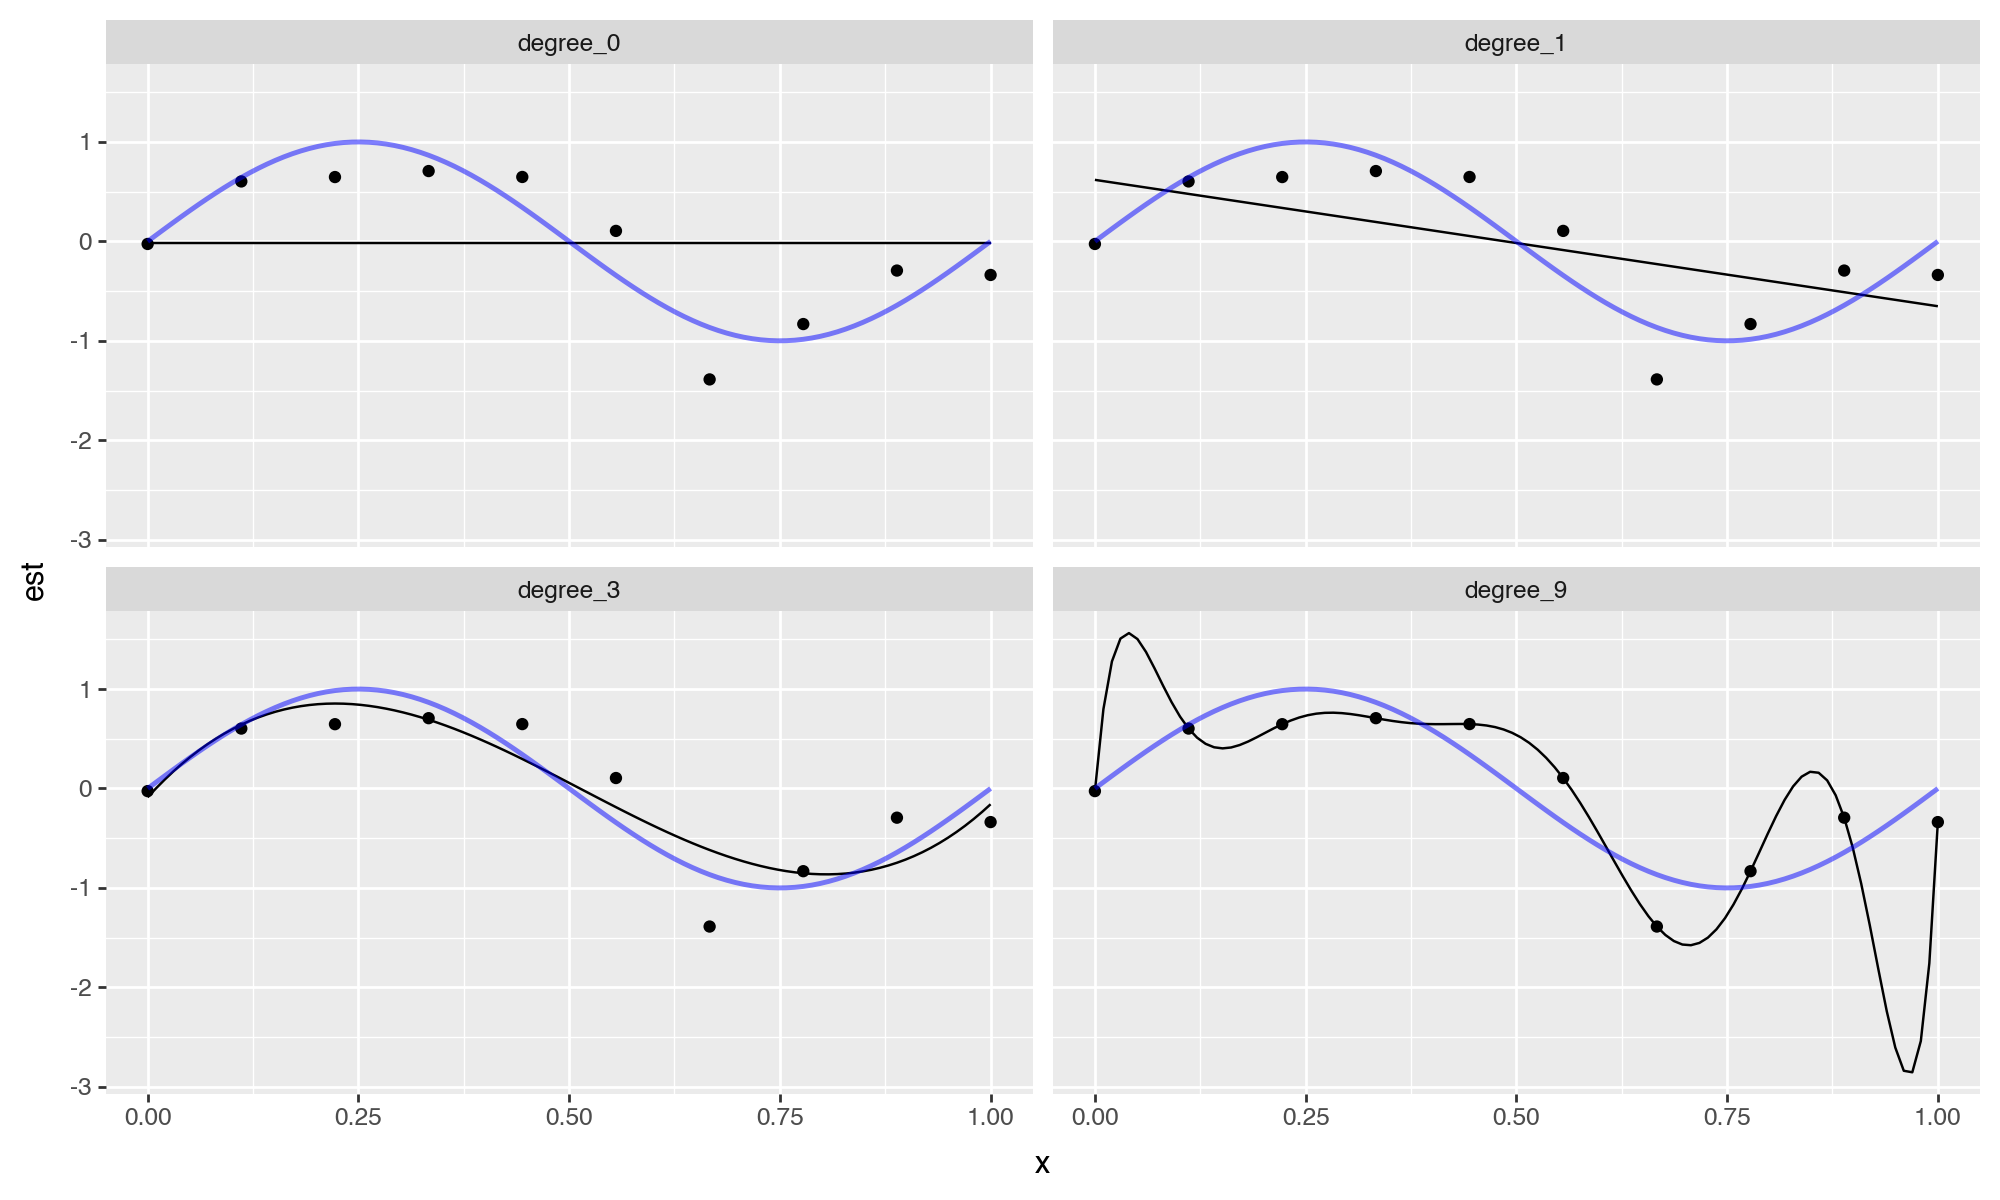

In [214]:
(
    ggplot(X_pred, aes('x', 'est')) + 
    geom_line() +
    geom_point(df, aes('x','y')) + 
    geom_line(df_sin, aes('x', 'y'), color='blue', size=1, alpha = 0.5) + 
    facet_wrap('~degree') +
    theme(figure_size= (10,6))
)

We can clearly see that the constant ($m=0$
) and first order ($m=1$
) polynomials give rather poor fits to the data and consequently rather poor representations of the function $\sin(2\pi x)$
.


These two polynomial fits fail to capture the underlying trend of the data. A high error can be computed between the predicted and the actual data samples. These are examples of <u>under-fitting</u>.

The third order ($m=3$
) polynomial seems to give the best fit to the function $\sin(2\pi x)$ 
. 

By selecting $m = 3$
 in the previous example, we observe an appropriate balance between capturing the trends in the data to achieve good generalization and making accurate predictions for outcome values.



When we go to a much higher order polynomial ($m=9$
), we obtain a polynomial that passes exactly through each data point. 

However, the fitted polynomial fails to give a good representation of the function $\sin(2 \pi x)$
. 

The fitted curve considers each deviation in the data points (including noise). <u>The model is too sensitive to noise</u> and captures random patterns which are present only in the current dataset.

Poor generalization to other datasets is expected. This latter behavior is known as <u>over-fitting</u>.

It is particularly interesting to examine the behavior of a given model as the size of the data set varies. 

We can see that, for a given model complexity, the over-fitting problem become less severe as the size of the data set increases. In our example, by considering not only $10$
, but $n = 15$ 
 or $n = 100$
 data points, we observe that increasing the size of the data set reduces the over-fitting problem (see Figure below).

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_68576/3025566215.py:42: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


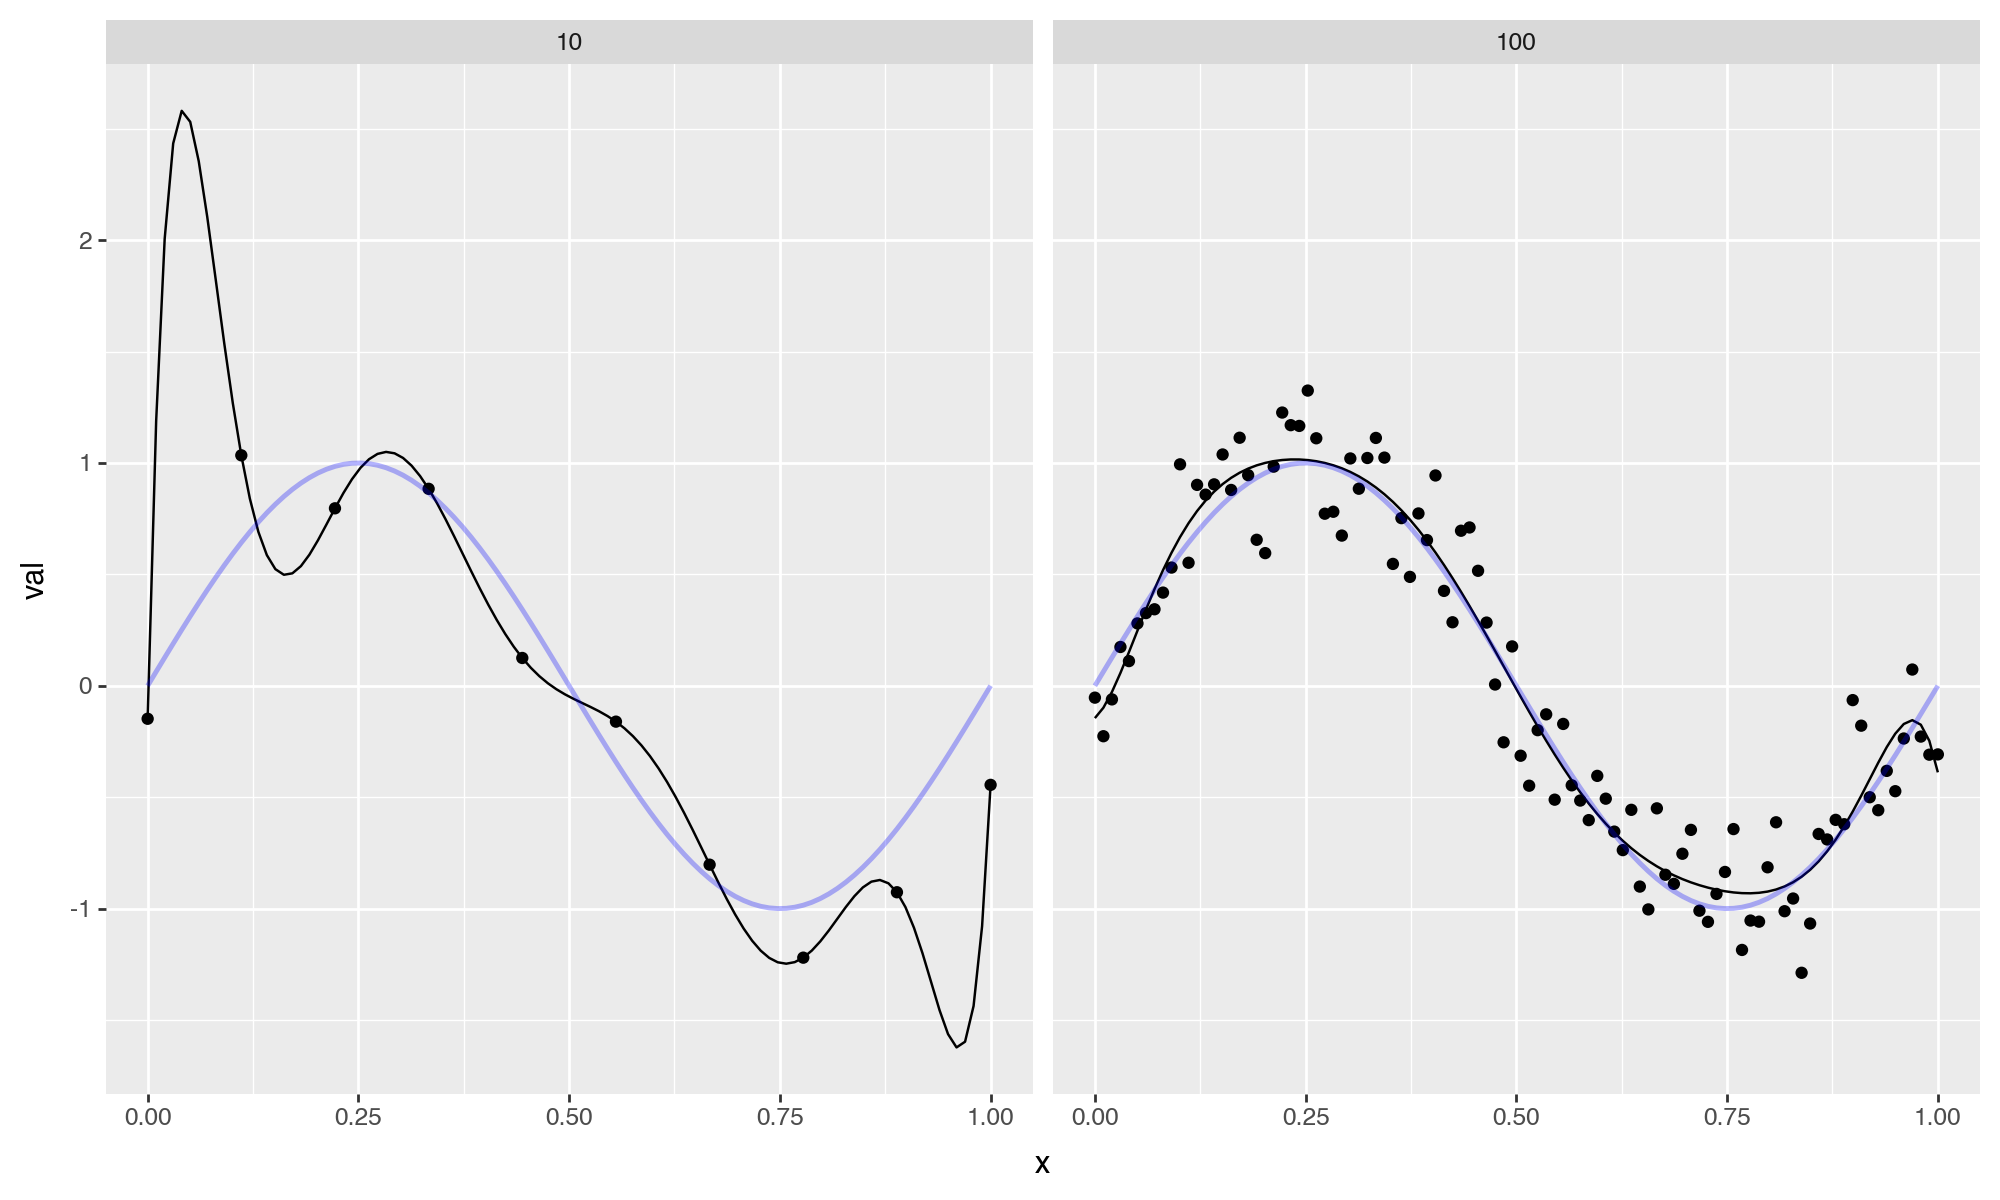

In [215]:
n = 100
m = 10

points = np.linspace(0,1,n)
sin_p = np.sin(2*np.pi*points)
noise = np.random.normal(loc = 0, scale= 0.2, size = len(points))

df1 = pd.DataFrame({
    'x' : points,
    'y' : sin_p + noise,
    'n' : n
})

points = np.linspace(0,1,m)
sin_p = np.sin(2*np.pi*points)
noise = np.random.normal(loc = 0, scale= 0.2, size = len(points))

df2 = pd.DataFrame({
    'x' : points,
    'y' : sin_p + noise,
    'n' : m
})


for i in range(1,10):
    df1['x_'+str(i)] = np.pow(df1['x'], i)
    df2['x_'+str(i)] = np.pow(df2['x'], i)


x = np.linspace(0,1,100)
X_pred = pd.DataFrame({'x': x})

for i in range(1,10):
    X_pred['x_'+str(i)] = np.pow(X_pred['x'], i)

for i,df in enumerate([df1, df2]):
    fit_model_x9 = smf.ols('y ~ x_1 + x_2 + x_3 + x_4 + x_5 + x_6 + x_7 + x_8 + x_9', df).fit()

    X_pred['pred' + str(i+1)] = fit_model_x9.predict(X_pred)

X_pred = X_pred.melt(id_vars= ['x'], value_vars= ['pred1','pred2'], value_name= 'val', var_name= 'n')
X_pred['n'] = X_pred['n'].replace({
    'pred1': n,
    'pred2': m
})

(
    ggplot(X_pred, aes('x','val')) +
    geom_point(df1, aes('x', 'y')) + 
    geom_point(df2, aes('x', 'y')) +
    geom_line() +
    geom_line(df_sin, aes('x', 'y'), color='blue', size=1, alpha = 0.3) + 
    facet_wrap('~ n') +
    theme(figure_size= (10,6))
)

    


This example, borrowed from the Christopher Bishop’s textbook, is very informative about the approach taken in and the issues faced by supervised learning.

First, supervised learning methods are more or less agnostic of the underlying processes. 

In our example, the underlying function is a sine. We may be looking at tides, an oscillating spring, etc. A physicist could come up with a model that leads to the right class of mathematical function. 

In supervised learning, we simply work with a generic class of flexible mathematical functions (here the polynomials, but there are many others), which can in principle approximate any function. One implication is that we will not aim at interpreting the coefficients. We would not pretend that the coefficient of say $x^4$
has any physical meaning. 

A physicist would (and could!) in contrast interpret the amplitude or the period of the sine. In supervised learning, what guides our choice of the fit is data and only data. In particular, the complexity of the function we chose (here the order of polynomials) depends on how much data we have and not on theoretical considerations about the underlying process.

Second, the key issue is that it is easy with flexible mathematical functions to fit extremely well to a dataset. The challenge is not reducing the error on data at hand but the error on unseen data. Expected error on unseen data is called the generalization error. We will now investigate practical techniques to control the generalization error.

------

# Splitting The Dataset for Performance Assessment

As previously stated, a supervised learning task starts with an available dataset that we use to build a model so that this model will eventually be used in completely independent datasets, as shown in below figure.

<img src = 'images/Supervised Learning Introduction.png' width = 600>

The first challenge arises when we do not know these independent datasets. However, in such cases, we still want to make sure that our model is not only working well when applied to the available dataset but can generalize well to independent unknown datasets. 

In particular, we want to make sure that we are not over-fitting to the dataset that the model was trained on.

How to minimize error on data we have never seen? We will make the following assumption:

* We assume that the observations $x_i, i = 1,2,3,...,n$
 of our dataset and of unseen data are i.i.d., meaning they are independent observations of the same population.

Under this assumption, one common strategy to evaluate the performance of the model on independent datasets is to select a subset of our dataset and pretend it is an independent dataset.

As illustrated in below figure, we divide the available dataset into a <u>training set</u> and a <u>test set</u>. We will train our algorithm exclusively on the training set and use the test set only for evaluation purposes.

<img src = 'images/Supervised Learning Introduction (1).png' width = 600>

Typically, we select a small piece of the dataset so that we have as much data as possible to train. However, we also want the test set to be large enough to obtain a stable estimate of the performance of the model on independent datasets. 

Common choices for the size of the train set are to use <u>10%-30% of the data for testing</u> .

-------

# Over-fitting to the training dataset

Over-fitting can be detected when the measured error computed from a defined error function is notably larger for the test dataset than for the training dataset. 

Alternatively, one can use performance measurements such as precision or recall or visualize the performance of the model on the training vs. test dataset with ROC or precision-recall curves. Notable differences with the measurements or the plotted curves are signs of over-fitting.

In the previous example of the polynomial curve fitting, we can split the data consisting of $n = 10$
 data points into train and test datasets and compare the computed error for different polynomial orders $n$
. For $m=9$
, the computed root-mean-squared error for the test dataset notably increases while the error for the training dataset decreases.



-------

# Cross-validation

Cross-validation is often used as a strategy to assess the performance of a machine learning model that can help to prevent over-fitting.

In cross-validation the data is randomly split into a number k of folds (e.g. 3, 5 or 10), as illustrated in figure below.



<img src = 'images/Supervised Learning Introduction (2).png' width = 700>

Then, a model is repeatedly trained on $k-1$
folds and evaluated on the fold not used for training. 
 
In this manner, we train $k$
models with a different training dataset on each fold $i$
with $i \in \{1,2,...,k\}$
. 

After the $k$
models have been trained and evaluated on the respective left-out folds, evaluation metrics can be summarized into a combined evaluation metric.

Now, how do we pick $k$
for the number of folds? Large values of $k$
are preferable because the training data better imitates the original dataset. However, larger values of $k$
will have much slower computation time: for example, 100-fold cross-validation will be 10 times slower than 10-fold cross-validation. For this reason, the choices of $k = 5$
and $k = 10$
are usually considered in practice.

## Pitfalls of Cross-validation

For considering cross-validation one fundamental assumption has to be met, namely that the <u>training samples and the test samples are independently and identically distributed (i.i.d.)</u>. 

As a trivial example, we would consider a non identical distribution if our training set consisted of red apples and green pears, but our test set also contained green apples. The issue of having non independent distributions may arise if we have data coming in clusters that we are not aware of (e.g: repeated measures, people from same families, homologous genes).

As an example of this issue, we consider a simulated dataset `simulated_df` consisting of a feature variable x and an outcome variable y:

We observe that the dataset contains repeated measures and that the between replicate simulated trend is $x=y$.

<img src = 'images/Supervised Learning Introduction (3).png' width = 500>

Performing cross-validation at the level of individual data points will favor models that learn the clusters:

<img src = 'images/Supervised Learning Introduction (4).png' width = 500>

We need to perform cross-validation at the cluster level to learn the trend across clusters.

However, this is difficult without application knowledge. Visualization techniques can help. Application areas may have their own strategies. 

In genetics, models are required to be replicated on independent populations (genetic associations on say Swedes must be replicated among say Germans). The issue also arises with temporal data. Cross-validation cannot be done by taking random subsets of past data points. For temporal data, it is common practice (and common sense) to test models by mimicking predictions of future time points. See a broader discussion of this issue by Roberts et al. (2017).

<img src = 'images/Supervised Learning Introduction (5).png' width = 500>

-------

# Cross-validation in Python


In Python, we can implement cross-validated models using `scikit-learn`. 

As an example, we implement a logistic regression model to solve the binary classification task from Chapter (chap-log-reg?), which consists in predicting the gender of a person based on height values of him/herself and his/her parents. First, we load the heights dataset:

In [216]:
heights_df = pd.read_csv('Datasets/height.csv')
heights_df = heights_df.iloc[:, :-1].dropna()
heights_df.head()

,height,sex,mother,father
0,150,F,170.0,177.0
1,152,F,157.0,175.0
2,152,F,155.0,156.0
3,153,F,155.0,175.0
4,153,F,150.0,176.0


In [217]:
heights_df['sex'] = heights_df['sex'].str.upper()
heights_df = heights_df[heights_df['sex'].isin(['M','F'])].copy()
heights_df.head()

,height,sex,mother,father
0,150,F,170.0,177.0
1,152,F,157.0,175.0
2,152,F,155.0,156.0
3,153,F,155.0,175.0
4,153,F,150.0,176.0


Then, we define the validation specification with `StratifiedKFold`. 

Here, we set the number of folds $k=5$ and we preserve class proportions in each fold.

In [218]:
from sklearn.model_selection import StratifiedKFold

k = 5
cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=0)

Next, we can train the model with `cross_validate`. Here, we optimize ROC-AUC for a logistic regression model:

In [219]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

X = heights_df.drop(columns=["sex"])
y = heights_df["sex"]

log_reg = LogisticRegression(max_iter=1000)

cv_results = cross_validate(
    log_reg,
    X, y,
    cv=cv,
    scoring={"roc_auc": "roc_auc"},
)

The cv_results dictionary returns the ROC-AUC values computed over the $k=5$ models. 

The performance measurements for each model can be obtained as follows:

In [220]:
pd.DataFrame({"roc_auc": cv_results["test_roc_auc"]})

,roc_auc
0,0.948614
1,0.960784
2,0.975232
3,0.985517
4,0.969655


Additionally, summary statistics can be computed:

In [221]:
roc_mean = cv_results["test_roc_auc"].mean()
roc_std = cv_results["test_roc_auc"].std()

pd.DataFrame(
    {
        "Mean ROC AUC": [roc_mean],
        "SD ROC AUC": [roc_std],
    }
).round(3)

,Mean ROC AUC,SD ROC AUC
0,0.968,0.013


The final model can be obtained by fitting a logistic regression model on the full dataset:

In [222]:
log_reg.fit(X, y)

coef = pd.Series(
    log_reg.coef_.ravel(),
    index=X.columns).sort_values(key=np.abs, ascending=False
)

coef.to_frame("coefficient")

,coefficient
height,0.507576
mother,-0.182792
father,-0.177412


--------

# Random Forests as Alternative Models

There is a plethora of supervised learning algorithms out there. 

Providing a reasonable survey of them is out of the scope of this module. 

We therefore introduce here a single supervised learning method beyond linear and logistic regression which is working well in many situations: Random forests. 

Just as linear and logistic regression should be the first baseline models to try, random forests can be seen as the first non-interpretable supervised learning model to give a shot for. 

From this basis, many other options can be considered, often depending on the application areas.

Random forests can be applied to both regression and classification tasks. In this section, we introduce random forests as a further type of model for solving both tasks, as these are easy to understand and achieve state-of-the-art performance in many prediction tasks.

Random forests are based on decision trees. 

More precisely, they are an instance of tree-based ensemble learning, which is a strategy robust to over-fitting and allows fitting very flexible functions. Each random forest is an ensemble of several decision trees, which are machine learning models for both classification and regression tasks and will be introduced in the following section.

## The Basics of Decision Trees

A decision tree is a method that involves partitioning or segmenting the training data set into a number of simple regions. Typically, once the input space of the training dataset has been segmented, we can make a prediction for a new input sample by using the mean or the mode of the training observations in the region to which the new input sample is assigned to.

### Decision trees for regression tasks

As an example for a decision tree model for a regression task, we consider the Hitters dataset to predict a baseball player’s (log-transformed) Salary based on the feature Years (the number of years that he has played in the major leagues) and on the feature Hits (the number of hits that he made in the previous year). 

A regression tree for this dataset is shown in figure below. The constructed tree consist of 3 splitting rules. First, observations having $\text{Years}<4.5$ get passed to the right branch and observations having $\text{Years}\geq4.5$ to the left branch. 

The predicted log-transformed salary for these players in the right is given by the mean log-transformed salary of all training samples in this node, which is in this case $5.11$. Players assigned to the left branch are further subdivided by the feature Hits.

<img src = 'images/Supervised Learning Introduction (6).png' width = 600>

After the training is finalized, the tree regions the players into three regions: players who have played for four or fewer years, players who have played for five or more years and who made fewer than $118$ hits last year, and players who have played for five or more years and who made at least $118$ hits last year. A graphical representation of this resulting segmentation can be observed in figure below.

<img src = 'images/Supervised Learning Introduction (7).png' width = 600>

Formally, the three resulting regions can be written as:

$$

\begin{aligned}
R_1 &= \{\, X \mid \text{Years} < 4.5 \,\} \\
R_2 &= \{\, X \mid \text{Years} \ge 4.5,\ \text{Hits} < 117.5 \,\} \\
R_3 &= \{\, X \mid \text{Years} \ge 4.5,\ \text{Hits} \ge 117.5 \,\}
\end{aligned}

$$

Here, $X$ is the dataset consisting of all training samples and the regions $R_1$
, $R_2$
 and $R_3$
 are the leaf nodes of the tree. All other nodes are denoted as internal nodes of the constructed decision tree.

Decision trees are easy to interpret. In our example, we can interpret the tree as follows:

* `Years` is the most important feature for predicting the log-transformed salary of a player. Players with less experience earn lower salaries than more experienced players.

* If a player is more experienced, the number of hits that he made in the previous year is important for determining his salary.



<u>Now… why and how did we choose the feature Years and the threshold of 4.5 for the top split? </u>

Overall, the goal of a decision tree for regression tasks is to find the optional regions $R_1,R_2,...,R_j$
 that minimize the residual sum of squares (RSS) given by:

$$

\sum_{j=1}^{J} \sum_{i \in R_j} \left( y_i - \hat{y}_{R_j} \right)^2

$$

where $\hat{y}_{R_j}$
 is the prediction for all samples in region $R_j$
, which is computed from the mean of the outcome value for the training samples in region $R_j$.

Unfortunately, it is computationally unfeasible to consider every possible partition of the training dataset. This is why <u>decision trees follow a top-down greedy approach to build the tree</u>. 

The approach is top-down because it begins at the top of the tree with the complete dataset and then successively splits the dataset. Here, each split results into two new branches further down on the tree. Note that the approach is greedy because at each step of the process, the best split is made at that particular step.

In order to perform recursive binary splitting, we first select the feature $X_j$
 and a threshold $s$
 such that splitting the samples into the regions $R_1 = \{X | X_j < s\}$
 and $R_2 = \{X | X_j \geq s\}$
 results into the greatest possible reduction in RSS. For this, we consider all possible features $X_1,...,X_p$
, and all possible values threshold values $s$
 for each feature.
 
  In greater detail, for any $j$
 and $s$
, we want to minimize the equation:

$$
\sum_{i \in R_{1(j,s)}} \left( y_i - \hat{y}_{R_1} \right)^2
\;+\;
\sum_{i \in R_{2(j,s)}} \left( y_i - \hat{y}_{R_2} \right)^2

$$


Note that finding optimal values for thresholds and features can be achieved quickly with the current advances in computer science assuming that the number of features is not too large.

The iterative process of finding features and thresholds that define splitting rules continues until a stopping criterion is met. This prevents to consider every possible partition of the training dataset. Stopping criteria include setting a minimum number of samples in a region or defining a maximum number of resulting regions.

Once the regions $R_1,..., R_j$ have been created, we can predict the outcome of any given sample (from the test set) by assigning this sample to a region and returning the mean of the training observations in the region to which that (test) sample belongs.

-------